In [19]:
import joblib
import shap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [9]:
rf_model = joblib.load("random_forest_final_model.pkl")

X_test_scaled = pd.read_csv("X_test_scaled.csv")

print("X_test shape:", X_test_scaled.shape)
print("Number of features:", len(X_test_scaled.columns))

X_test shape: (1126, 46)
Number of features: 46


In [10]:
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test_scaled)

print("SHAP values type:", type(shap_values))
print("SHAP values shape:", shap_values.shape)
print("Expected value:", explainer.expected_value)

SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (1126, 46, 2)
Expected value: [0.50012747 0.49987253]


In [11]:
shap_values_churn = shap_values[:, :, 1]
expected_value_churn = explainer.expected_value[1]

print("Churn SHAP shape:", shap_values_churn.shape)
print("Expected value for churn:", expected_value_churn)

Churn SHAP shape: (1126, 46)
Expected value for churn: 0.49987253069941245


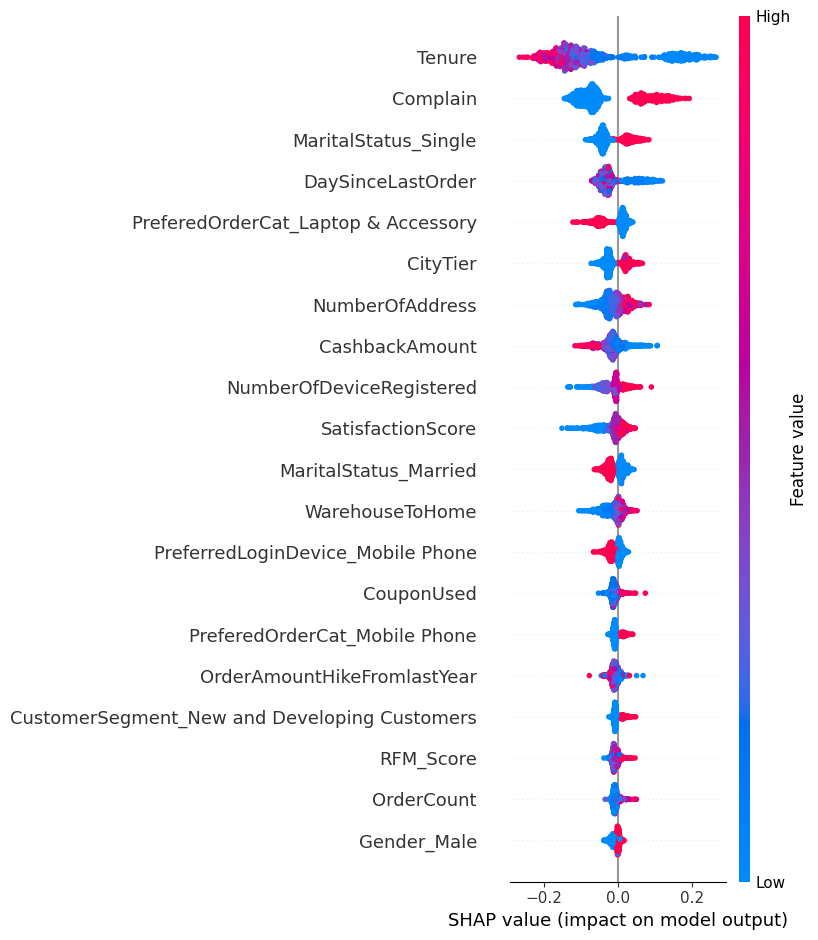

In [12]:
shap.summary_plot(
    shap_values_churn,
    X_test_scaled,
    feature_names=X_test_scaled.columns
)

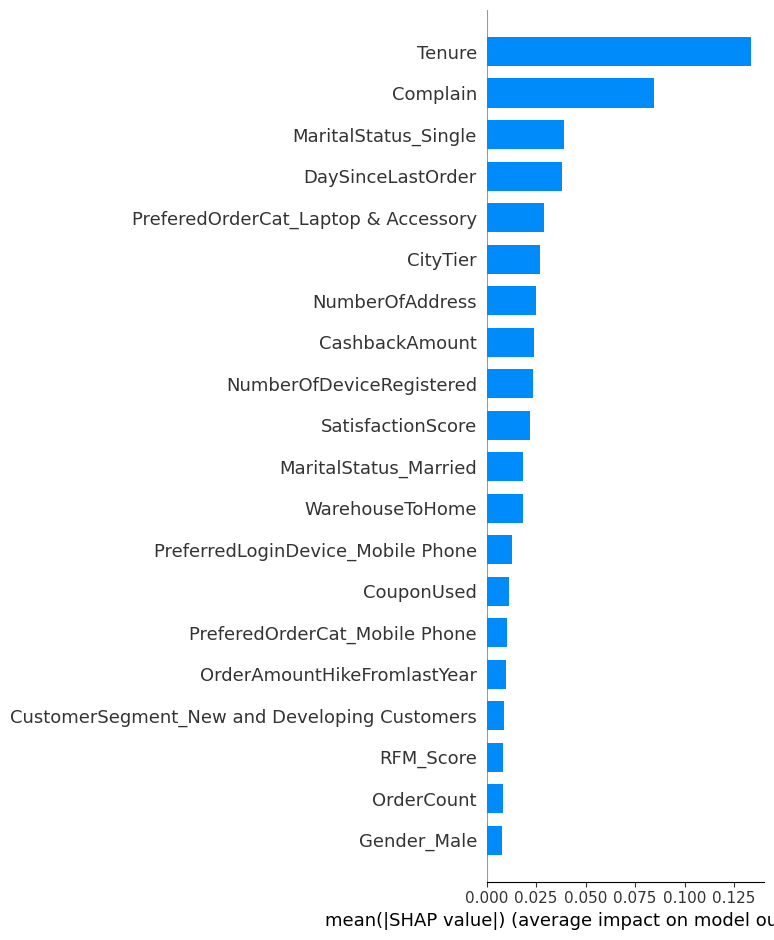

In [13]:
shap.summary_plot(
    shap_values_churn,
    X_test_scaled,
    feature_names=X_test_scaled.columns,
    plot_type="bar"
)

In [8]:
print(X_test_scaled.shape)

print(X_test_scaled.columns.tolist())

print(type(shap_values))

print(len(shap_values))

(1126, 46)
['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'RFM_Score', 'PreferredLoginDevice_Mobile Phone', 'PreferredLoginDevice_Phone', 'PreferredPaymentMode_COD', 'PreferredPaymentMode_Cash on Delivery', 'PreferredPaymentMode_Credit Card', 'PreferredPaymentMode_Debit Card', 'PreferredPaymentMode_E wallet', 'PreferredPaymentMode_UPI', 'Gender_Male', 'PreferedOrderCat_Grocery', 'PreferedOrderCat_Laptop & Accessory', 'PreferedOrderCat_Mobile', 'PreferedOrderCat_Mobile Phone', 'PreferedOrderCat_Others', 'MaritalStatus_Married', 'MaritalStatus_Single', 'R_Score_3', 'R_Score_2', 'R_Score_1', 'F_Score_2', 'F_Score_3', 'F_Score_4', 'M_Score_2', 'M_Score_3', 'M_Score_4', 'CustomerSegment_Frequent Low-Value Customers', 'CustomerSegment_High-Value Active Customers', 'CustomerSegment_High-Value Customers Lo

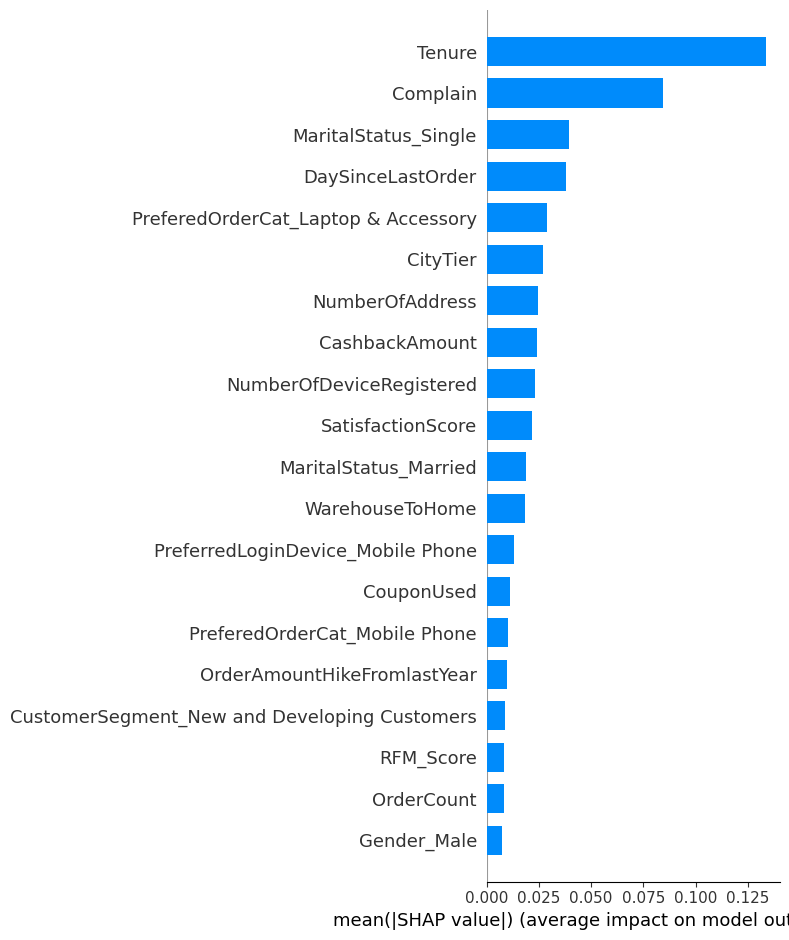

In [14]:
plt.figure()

shap.summary_plot(
    shap_values_churn,
    X_test_scaled,
    feature_names=X_test_scaled.columns,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.savefig("shap_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

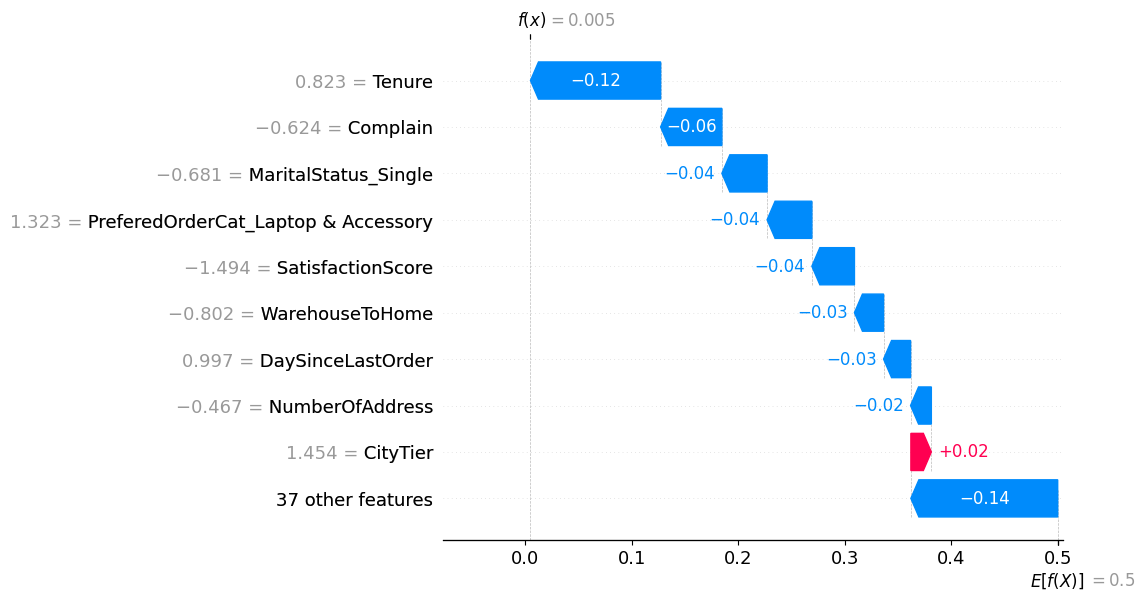

In [15]:
customer_index = 0

explanation = shap.Explanation(
    values=shap_values_churn[customer_index],
    base_values=expected_value_churn,
    data=X_test_scaled.iloc[customer_index],
    feature_names=X_test_scaled.columns
)

shap.plots.waterfall(explanation)

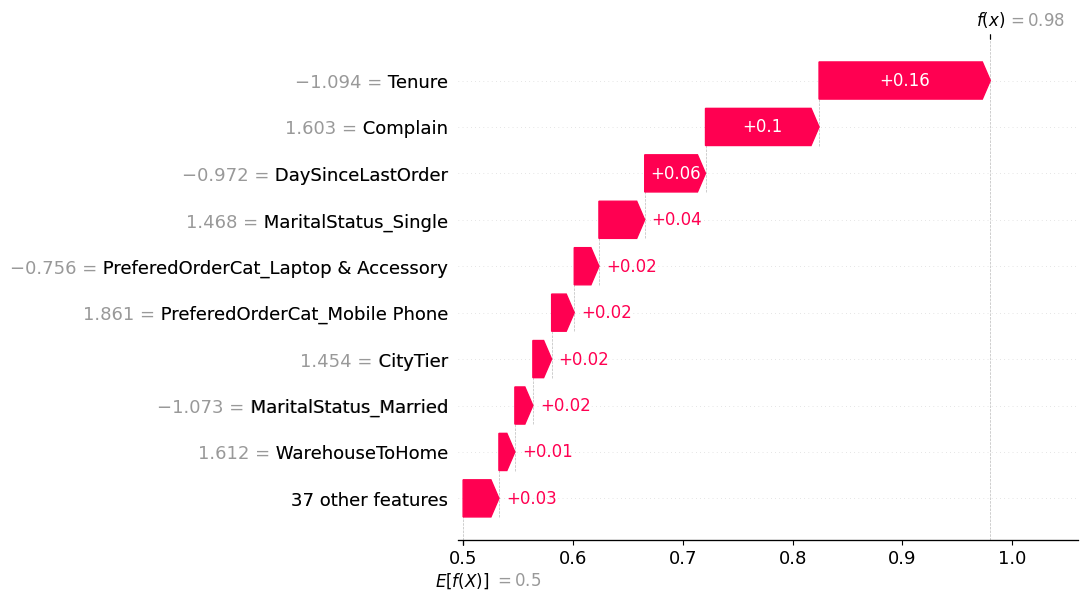

In [16]:
customer_index = 404

explanation = shap.Explanation(
    values=shap_values_churn[customer_index],
    base_values=expected_value_churn,
    data=X_test_scaled.iloc[customer_index],
    feature_names=X_test_scaled.columns
)

shap.plots.waterfall(explanation)

In [20]:
mean_abs_shap = np.abs(shap_values_churn).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": X_test_scaled.columns,
    "Mean_ABS_SHAP": mean_abs_shap
}).sort_values("Mean_ABS_SHAP", ascending=False)

shap_importance_df.head(15)

,Feature,Mean_ABS_SHAP
0,Tenure,0.133596
7,Complain,0.084407
29,MaritalStatus_Single,0.039259
11,DaySinceLastOrder,0.038167
24,PreferedOrderCat_Laptop & Accessory,0.028809
1,CityTier,0.026992
6,NumberOfAddress,0.024717
12,CashbackAmount,0.023934
4,NumberOfDeviceRegistered,0.023193
5,SatisfactionScore,0.021828


In [21]:
shap_importance_df.to_csv("shap_feature_importance.csv", index=False)

In [23]:
top_10_drivers = shap_importance_df.head(10)

top_10_drivers

,Feature,Mean_ABS_SHAP
0,Tenure,0.133596
7,Complain,0.084407
29,MaritalStatus_Single,0.039259
11,DaySinceLastOrder,0.038167
24,PreferedOrderCat_Laptop & Accessory,0.028809
1,CityTier,0.026992
6,NumberOfAddress,0.024717
12,CashbackAmount,0.023934
4,NumberOfDeviceRegistered,0.023193
5,SatisfactionScore,0.021828
